# Data

In [141]:
import os
import functions
import pandas as pd
import optuna
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import joblib
import numpy as np
import shap

csvs = [file for file in os.listdir('./Data/LondonHydro/') if file.endswith('.csv')]
df_name = csvs[0]
df = pd.read_csv(f'./Data/LondonHydro/{df_name}')

numerical_columns = ['energy_consumption', 'temperature', 'humidity', 'wind_speed']
categorical_columns = None
binary_columns = None
datetime_column = 'timestamp'
target_column = 'energy_consumption'

df[target_column] = df[target_column] + 1

df = functions.pre_process(df, numerical_columns, categorical_columns, binary_columns, datetime_column, target_column)

df = functions.get_datetime_features(df, datetime_column, cos_sin = False)

feature_names = ["Hour", "DayOfWeek", "DayOfMonth", "Month", "DayOfYear", "IsWeekend", "temperature", "humidity", "wind_speed", "energy_consumption"]
df = df[feature_names]

#scale type = both, features, outcome
X_train, y_train, X_val, y_val, X_test, y_test, X, y, df_scaled = functions.load_and_preprocess_data_with_sequences(df, target='energy_consumption', scaled=True, scale_type='features', val_ratio=0.1, test_ratio=0.1, input_seq_length=48, output_seq_length=24)

# Print shapes to verify
print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

df_scaled.head()


Shapes:
X_train: (20391, 48, 10)
y_train: (20391, 24, 1)
X_val: (2548, 48, 10)
y_val: (2548, 24, 1)
X_test: (2548, 48, 10)
y_test: (2548, 24, 1)


,Hour,DayOfWeek,DayOfMonth,Month,DayOfYear,IsWeekend,temperature,humidity,wind_speed,energy_consumption
timestamp,,,,,,,,,,
2002-01-01 01:00:00,0.043478,0.166667,0.0,0.0,0.0,0.0,0.312925,0.760000,0.270270,1.29
2002-01-01 02:00:00,0.086957,0.166667,0.0,0.0,0.0,0.0,0.302721,0.786667,0.270270,1.27
2002-01-01 03:00:00,0.130435,0.166667,0.0,0.0,0.0,0.0,0.287415,0.826667,0.256757,1.31
2002-01-01 04:00:00,0.173913,0.166667,0.0,0.0,0.0,0.0,0.278912,0.853333,0.175676,1.25
2002-01-01 05:00:00,0.217391,0.166667,0.0,0.0,0.0,0.0,0.277211,0.853333,0.148649,1.30


# HyperParameter and Training the best model

In [ ]:
model_types = ['LSTM', 'GRU', 'BLSTM', 'BGRU', 'CNN', 'TCN', 'DCNN', 'WaveNet', 'TFT', 'TST']
# model_types = ['LSTM']

# Example usage
data = (X_train, y_train, X_val, y_val, X_test, y_test)

for model_type in model_types:
    # best_model = functions.optimize_and_save_model(data, df_name, n_trials=5, epochs=100, verbosity=0, model_type=model_type)
    best_rf = functions.optimize_and_save_rf_model(data, df_name, n_trials=5, verbosity=1, model_type=model_type)
    functions.save_importance_plots(df_name, X_train, features_name=df.columns, model_type=model_type)

638/638 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step


[I 2024-08-27 19:30:07,913] A new study created in memory with name: no-name-3cea8889-ac8c-4eab-b850-d65be50d37e3


# Explaination general approach

80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
9400/9400 ━━━━━━━━━━━━━━━━━━━━ 51s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


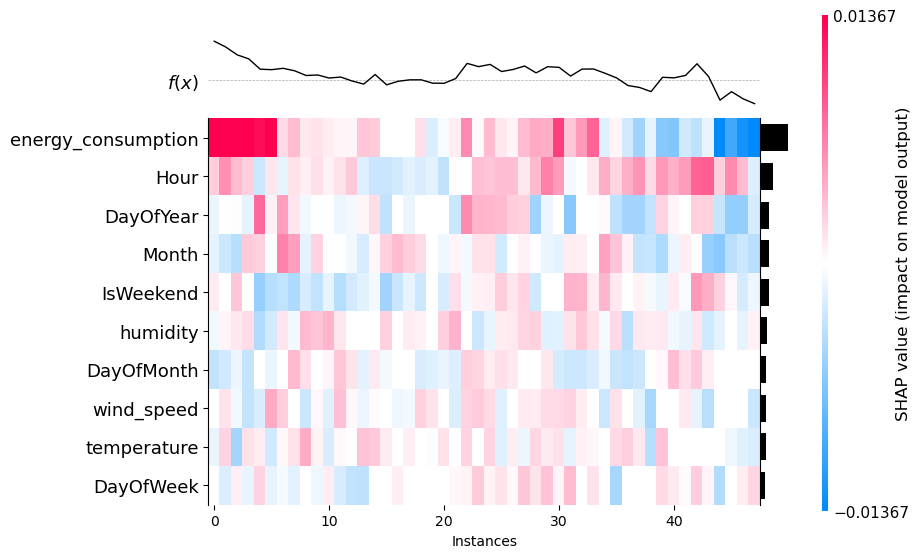

<Axes: xlabel='Instances'>

In [166]:
data = X_train, y_train, X_val, y_val, X_test, y_test
model_type="LSTM"
anomalies = load_and_analyze_model(data=data, df_name=df_name, model_type=model_type)
test_record=anomalies[0]

result = myshap(df_name=df_name, data=data, test_record=test_record, features_name=df.columns, model_type=model_type, horizon=0, similar_background=False, weighted=False, num_neighbors=100)

explanation = shap.Explanation(values=np.array(result['shap_df']), base_values=np.full((result['shap_df'].shape[0],), result['baseline_prediction']), data=result['new_data'], feature_names=result['features_name'])
shap.plots.heatmap(explanation)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
9119/9119 ━━━━━━━━━━━━━━━━━━━━ 58s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


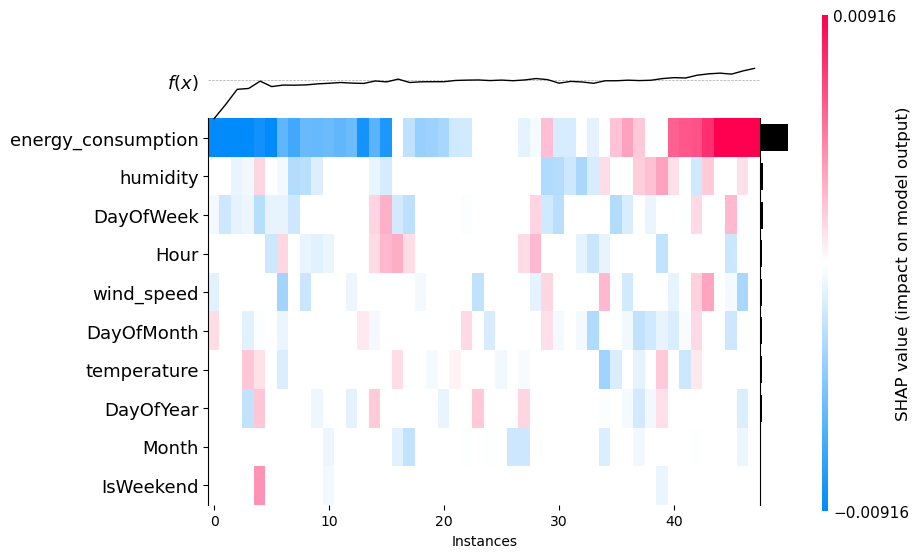

<Axes: xlabel='Instances'>

In [181]:
data = X_train, y_train, X_val, y_val, X_test, y_test
result = myshap(df_name=df_name, data=data, test_record=test_record, features_name=df.columns, model_type=model_type, horizon=0, similar_background=True, weighted=False, num_neighbors=100)

explanation = shap.Explanation(values=np.array(result['shap_df']), base_values=np.full((result['shap_df'].shape[0],), result['baseline_prediction']), data=result['new_data'], feature_names=result['features_name'])
shap.plots.heatmap(explanation)


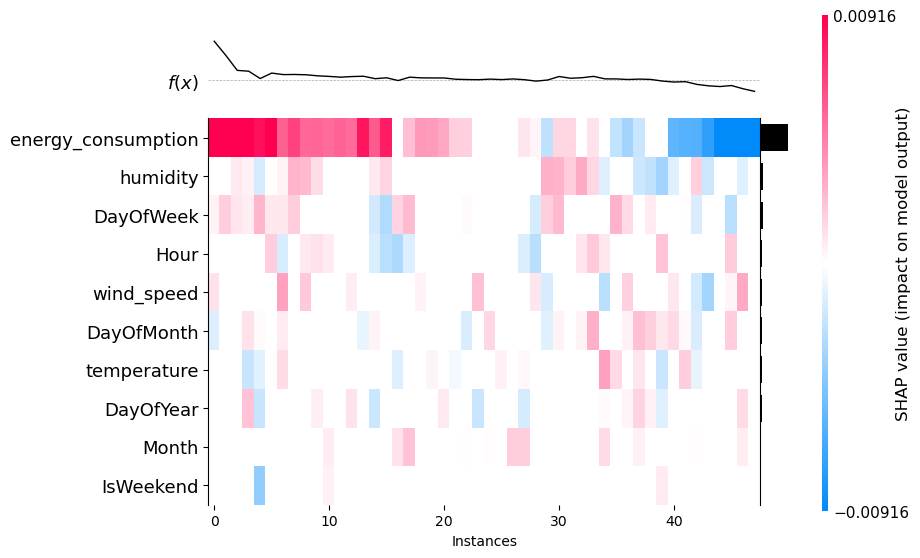

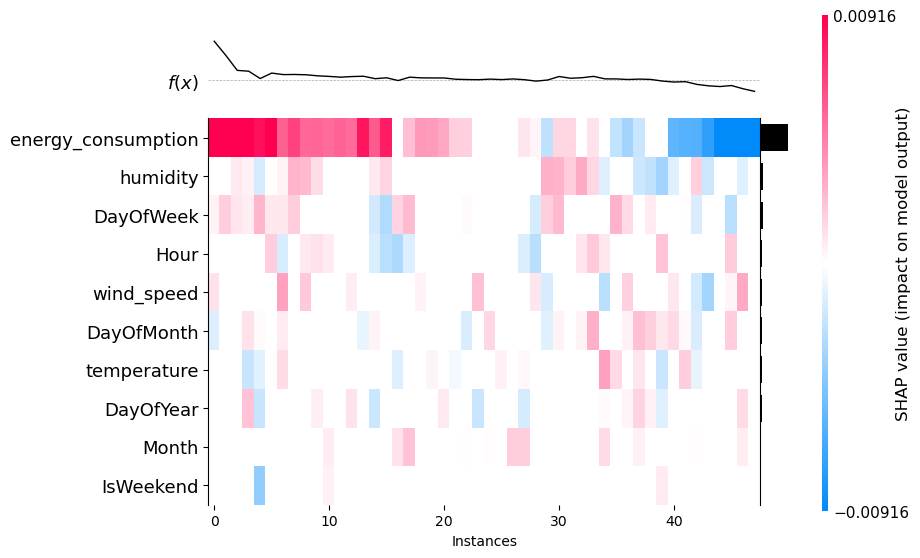

In [205]:
explanation = shap.Explanation(values=np.array(result['shap_df']), base_values=np.full((result['shap_df'].shape[0],), result['baseline_prediction']), data=result['new_data'], feature_names=result['features_name'])
shap.plots.heatmap(explanation)

# Create a Matplotlib figure
plt.figure(figsize=(10, 6))

# Generate the heatmap plot using SHAP
shap.plots.heatmap(explanation, show=False)

# Save the plot as a PDF
save_path = f"./Results/Plots/{df_name}/SHAP_heatmap_{model_type}.pdf"
plt.savefig(save_path, format='pdf', bbox_inches='tight')

# Optionally show the plot
plt.show()

# Close the plot to free up memory
plt.close()


In [201]:
input_time = 0
explanation = shap.Explanation(values=np.array(result['shap_df'])[input_time,:], base_values=result['baseline_prediction'], data=result['new_data'][:,input_time,:], feature_names=result['features_name'])
shap.initjs()
shap.force_plot(explanation.base_values, explanation.values, explanation.data, feature_names=explanation.feature_names)